# Arc-Length Controlled Shape Design

Numerical demonstrations behind

> Bouwer, J. M., Kok, S. and Wilke, D. N. (2023). *Challenges and solutions to
> arc-length controlled structural shape design problems.* Mechanics Based Design of
> Structures and Machines, **51**(7), 4088–4119.
> [doi:10.1080/15397734.2021.1950549](https://doi.org/10.1080/15397734.2021.1950549)

1. **Large arc-length steps pay for themselves** in solution time.
2. **A four-variable design space** — different design radii give different arches.
3. **Those arches solved with Q8 elements**, giving their load-deflection paths.
4. **The objective function** comparing a computed load path to a target, with its
   analytical gradient — the paper's equations (9) and (10), both interpolation schemes.
5. **SLSQP walking into a discontinuity** — declaring success 10.7 mm from a known optimum,
   which is the paper's central claim.
6. **A gradient-only optimiser getting further** — ADAM, which never reads the objective
   value, halving that error on the same problem.

The discontinuity study and the paper's own gradient-only methods are the next piece, and
are not here yet. [`README.md`](README.md) carries the discussion and the numbers; this
notebook keeps to the code.

> **A full re-run takes about two hours**, of which section 5 is 86 minutes and section 6 a
> further 24 — every objective evaluation is an arc-length solve carrying sensitivities.
> The notebook is committed with its output, so it reads without being executed.

In [1]:
import contextlib
import logging
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

from fem2d.meshers import Mesh, Q8Mesh
from fem2d.postprocessing import Plotting
from fem2d.solvers import ArcLengthSolver

logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    # The solvers log every iteration; silence them for the sweeps.
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)

## The structure

The paper's arch: a deep circular arch spanning 270°, clamped at one end and pinned at the
other, loaded at the crown. The asymmetry is deliberate — it makes the arch deform towards
the softer pinned side, and unfolds what would otherwise be a symmetric buckling
bifurcation into a smooth path through a limit point.

The paper does not publish the material constants, so the section here is a choice: the
radial depth is set so that $I/A = h^2/12 = 1$, giving $h = \sqrt{12}$ and $EA = EI$, with
$E = 210$ GPa. Load factors are therefore not the paper's, but $\lambda$ is exactly linear
in $E$, so they are one constant away from them.

In [2]:
h = 12**0.5
E = 210000.0                   # 210 GPa, in N and mm
v, t, plane = 0.3, 1.0, 0      # plane stress: a beam of unit width
R = 100.0                      # base radius, held at the two ends
Span = 270.0                   # the paper's arch, -45 to 225 degrees
Load = -1.0                    # unit point load at the crown, scaled by the load factor

def Arch(ElementType, el_num, radii):
    m = (Q8Mesh if ElementType == 'Q8' else Mesh)(E, v, t, plane, ElementType)
    m.SemiCircularArch(el_num, R, list(radii), h, Load, Span=Span)
    return m


ElNum = 20

ArcStep, ArcTotal = 200, 2600


20 elements, 103 nodes, 4 design variables


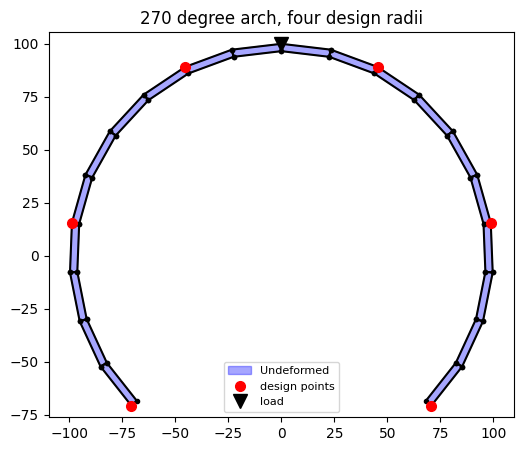

In [3]:
m = Arch('Q8', ElNum, [R]*4)

ax = Plotting.InitialMesh(m, alpha=0.35)
ax.plot(m.VarPos[0], m.VarPos[1], 'ro', ms=7, label='design points')
ax.plot(m.Nodes[m.LoadNode//2, 1], m.Nodes[m.LoadNode//2, 2], 'kv', ms=10, label='load')
ax.set_title(f'{Span:.0f} degree arch, four design radii')
ax.legend(loc='lower center', fontsize=8)
ax.figure.set_size_inches(6, 5)
print(f'{m.Elements.shape[0]} elements, {m.Nodes.shape[0]} nodes, '
      f'{m.VariableNumber} design variables')

## 1. Why large arc-length steps pay

The arc-length method walks along the equilibrium path in fixed increments of arc length
rather than of load, which is what lets it round a limit point. The prescribed step is a
free choice, and when a step will not converge the solver halves it by $\sqrt{2}$ and
retries.

Small steps look safe but cost time. Large steps cover ground quickly but start to
trigger those retries. Sweeping the prescribed arc length on one fixed design shows both
ends of that trade.

In [4]:
class CountCuts(logging.Handler):
    # The solver logs a line whenever it reduces the arc step.
    def __init__(self):
        super().__init__()
        self.cuts = 0

    def emit(self, record):
        if 'cutting' in record.getMessage():
            self.cuts += 1


Total = 800.0
Sweep = [640.0, 320.0, 160.0, 80.0, 40.0, 20.0, 10.0]
Rows = []

for ArcLength in Sweep:
    Counter = CountCuts()
    SolverLog.handlers = [Counter]
    SolverLog.setLevel(logging.INFO)
    # The counter needs the records, but they must not also reach the root
    # handler, or every iteration lands in the notebook output.
    SolverLog.propagate = False

    m = Arch('5B', 20, [R]*4)
    Start = time.perf_counter()
    ArcLengthSolver(m, ArcLength=ArcLength, TotalArcLength=Total, tol=1e-6, MaxIter=9).Solve()
    Elapsed = time.perf_counter() - Start

    Lam = np.ravel(m.LoadValues)
    Rows.append((ArcLength, len(Lam) - 1, Counter.cuts, Elapsed, Lam.max()))

SolverLog.handlers = []
SolverLog.propagate = True

print(f"{'arc length':>11}{'steps':>7}{'cuts':>6}{'time (s)':>10}{'lambda max':>12}")
for ArcLength, Steps, Cuts, Elapsed, LamMax in Rows:
    print(f'{ArcLength:>11.1f}{Steps:>7}{Cuts:>6}{Elapsed:>10.2f}{LamMax:>12.1f}')

 arc length  steps  cuts  time (s)  lambda max
      640.0      7    34      7.66       235.7
      320.0      7    20      5.00       235.7
      160.0      7     6      2.34       235.7
       80.0     10     0      1.54       236.9
       40.0     21     3      2.53       237.2
       20.0     41     2      4.03       237.4
       10.0     80     0      6.95       237.4


`lambda max` barely moves across the sweep, so every run traced the same path and the times
are comparable. The cost is **U-shaped, not monotonic**: small steps cost many steps, large
steps cost retries, and the cheapest setting is the largest step that is not provoking many
of them. The paper's Table 1 shows only the rising half.

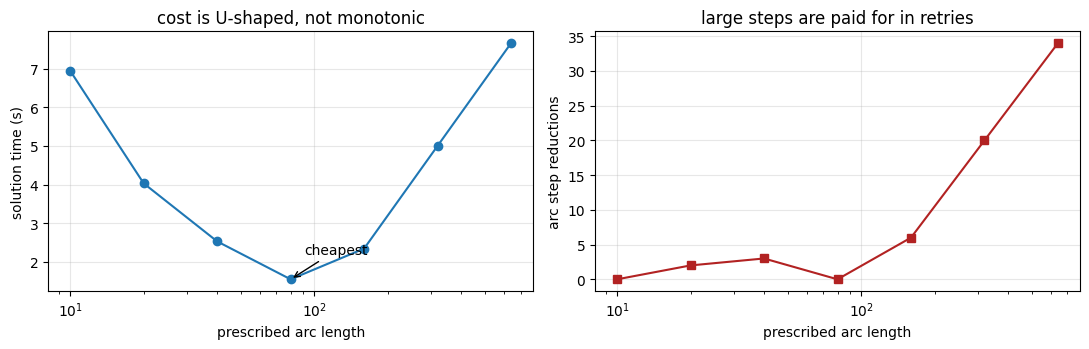

In [5]:
ArcLengths = [r[0] for r in Rows]
Times = [r[3] for r in Rows]
Cuts = [r[2] for r in Rows]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))

a1.plot(ArcLengths, Times, 'o-')
a1.set(xscale='log', xlabel='prescribed arc length', ylabel='solution time (s)',
       title='cost is U-shaped, not monotonic')
a1.grid(alpha=0.3)
Best = int(np.argmin(Times))
a1.annotate('cheapest', xy=(ArcLengths[Best], Times[Best]),
            xytext=(10, 18), textcoords='offset points',
            arrowprops=dict(arrowstyle='->'))

a2.plot(ArcLengths, Cuts, 's-', color='firebrick')
a2.set(xscale='log', xlabel='prescribed arc length', ylabel='arc step reductions',
       title='large steps are paid for in retries')
a2.grid(alpha=0.3)
plt.tight_layout()

## 2. The four-variable design space

The shape parameters are the arch radius at four equally spaced angles. The two ends stay
at 100 mm and a cubic spline runs the radius through all six points, so a design is four
numbers and the arch follows.

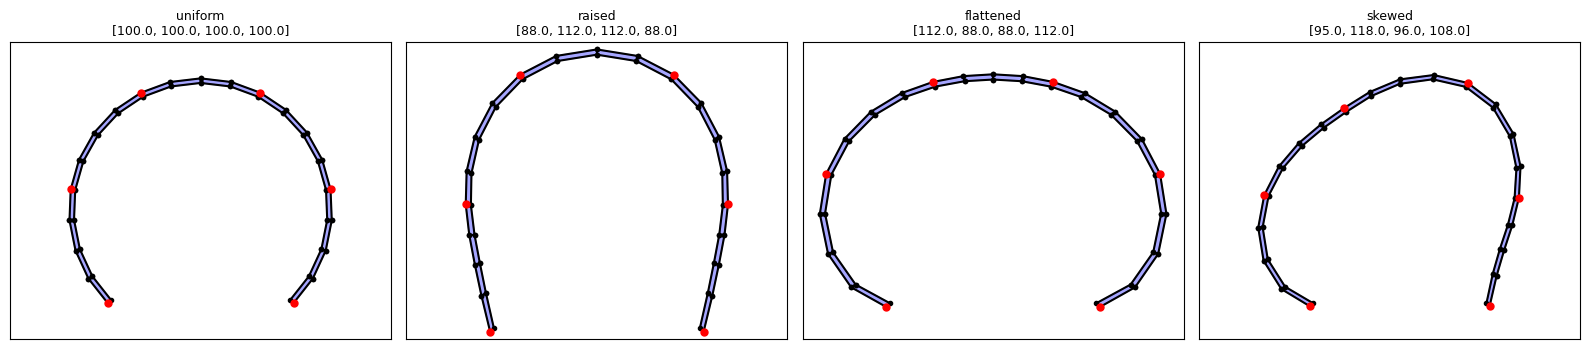

In [6]:
Designs = {
    'uniform':   [R, R, R, R],
    'raised':    [88.0, 112.0, 112.0, 88.0],
    'flattened': [112.0, 88.0, 88.0, 112.0],
    # The obvious skewed choice, 92 at the first station, cannot be traced: it
    # runs into a very sharp limit point at an accumulated arc length of 1088
    # that no amount of arc step cutting gets past. So do 91 and 93; 95 is fine.
    # The paper reports the same thing, that parts of this design space produce
    # load paths its solver could not follow.
    'skewed':    [95.0, 118.0, 96.0, 108.0],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (Name, radii) in zip(axes, Designs.items(), strict=True):
    m = Arch('Q8', ElNum, radii)
    Plotting.InitialMesh(m, ax=ax, alpha=0.35)
    ax.plot(m.VarPos[0], m.VarPos[1], 'ro', ms=5)
    ax.set_title(f'{Name}\n{radii}', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## 3. Load paths, solved with Q8

Each design traced with the arc-length solver on eight-node elements, at a deliberately
loose residual tolerance.

`peak load` is the largest load factor *recorded*, which is a limit load only when the peak
is interior — so the cell says which case each design is in. `END OF TRACE` means the load
was still climbing when the arc length ran out, and the number is just where the trace
stopped rather than a buckling load.

Whether a design also snaps *back* — the crown reversing — likewise depends on how far the
path is traced, so that too is reported from the data rather than assumed.

In [7]:
Paths = {}
print(f"{'design':<11}{'steps':>6}{'time (s)':>9}{'peak load':>11}{'u at peak':>11}"
      f"{'u reached':>11}   {'peak is':<15}turns back?")
for Name, radii in Designs.items():
    m = Arch('Q8', ElNum, radii)
    Start = time.perf_counter()
    with quiet():
        ArcLengthSolver(m, ArcLength=ArcStep, TotalArcLength=ArcTotal,
                        tol=1e-2, MaxIter=9).Solve()
    Paths[Name] = m

    Lam = np.ravel(m.LoadValues)
    U = m.AllU[m.LoadNode, :]
    Peak = int(np.argmax(Lam))

    # The largest recorded load factor is a limit load only when the peak is
    # interior. Landing on the last point means the load was still climbing when
    # the arc length ran out, so the number is just where the trace stopped.
    Kind = 'a limit point' if Peak < len(Lam) - 1 else 'END OF TRACE'

    # A reversal in the crown displacement is snap-back; report it from the data
    # rather than asserting it, since it depends on how far the path was traced.
    Back = np.flatnonzero(np.diff(U) > 0)
    Turns = (f'yes, {U[-1] - U.min():.1f} mm at u={U.min():.1f}' if len(Back)
             else 'no, not within this arc length')

    print(f'{Name:<11}{len(Lam)-1:>6}{time.perf_counter()-Start:>9.1f}{Lam.max():>11.1f}'
          f'{U[Peak]:>11.1f}{U.min():>11.1f}   {Kind:<15}{Turns}')

design      steps time (s)  peak load  u at peak  u reached   peak is        turns back?


uniform        18     11.5      277.3      -97.0     -226.7   a limit point  no, not within this arc length


raised         15      6.9      209.1      -86.9     -214.4   a limit point  no, not within this arc length


flattened      17     10.4      801.8     -232.0     -232.0   END OF TRACE   no, not within this arc length


skewed         15      7.1      193.3     -101.3     -230.9   a limit point  no, not within this arc length


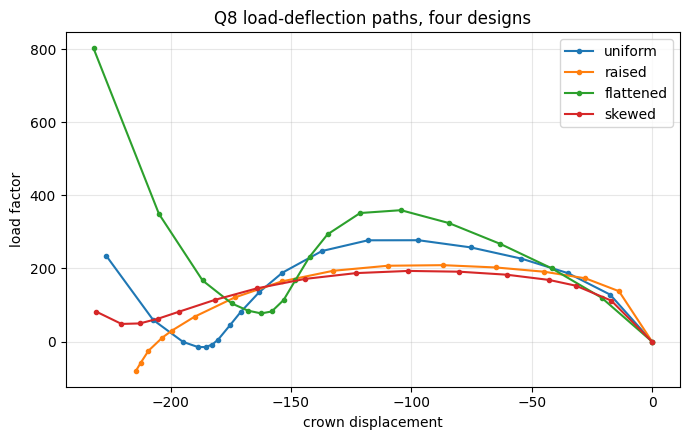

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for Name, m in Paths.items():
    ax.plot(m.AllU[m.LoadNode, :], np.ravel(m.LoadValues), 'o-', ms=3, label=Name)
ax.set(xlabel='crown displacement', ylabel='load factor',
       title='Q8 load-deflection paths, four designs')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

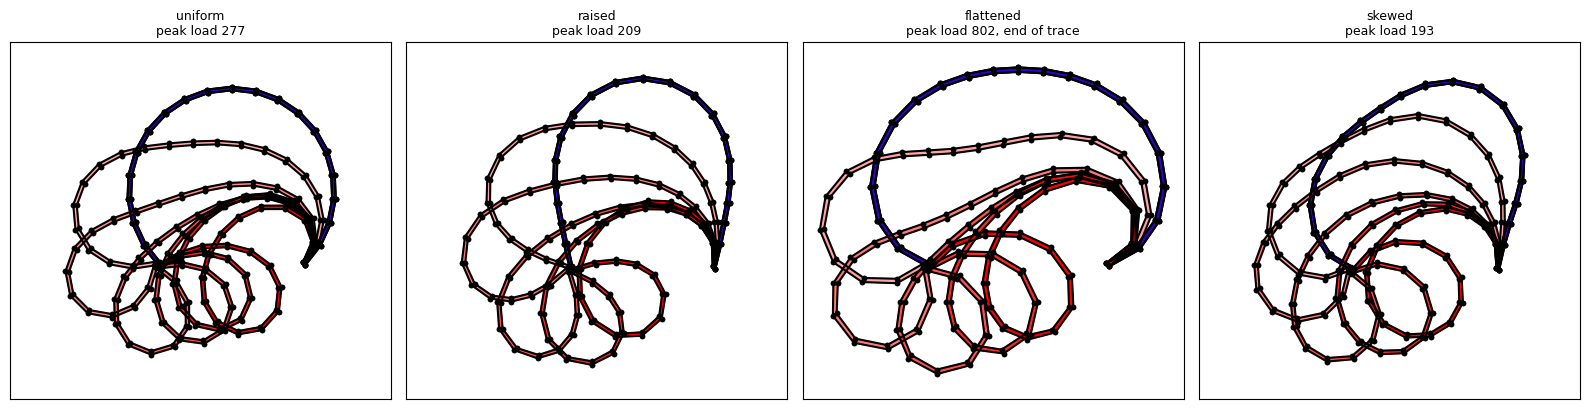

In [9]:
# The deformed shapes behind the four load paths above, faded in step by step.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (Name, m) in zip(axes, Paths.items(), strict=True):
    Plotting.Overlay(m, ax=ax, steps=max(1, m.AllU.shape[1]//5))

    # Only call it a limit load when the peak is interior; otherwise the trace
    # simply stopped there with the load still rising.
    Lam = np.ravel(m.LoadValues)
    Tag = '' if int(np.argmax(Lam)) < len(Lam) - 1 else ', end of trace'
    ax.set_title(f'{Name}\npeak load {Lam.max():.0f}{Tag}', fontsize=9)

    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## 4. The objective function

Two load paths are not sampled at the same places, so the paper treats both as parametric
curves in accumulated arc length and interpolates linearly. That leaves a choice:
**objective A** interpolates the target onto the design's arc lengths, **objective B**
interpolates the design onto the target's. Either way the error is equation (9), over the
load factor and the crown displacement:

$$\mathrm{MSE} = \frac{1}{N}\sum_i^N (\lambda^T_i - \lambda^d_i)^2
              + \frac{1}{N}\sum_i^N (u^T_i - u^d_i)^2$$

with $N$ the design's step count (A) or the target's point count (B). Both terms are scaled
by the target's range first so load and displacement weigh equally.

Its gradient is equation (10),

$$\frac{d\,\mathrm{MSE}}{dx} = -\frac{2}{N}\sum_i^N (\lambda^T_i - \lambda^d_i)
  \frac{d\lambda^d_i}{dx} - \frac{2}{N}\sum_i^N (u^T_i - u^d_i)\frac{du^d_i}{dx}$$

which needs the derivative of the arc lengths the interpolation is built on. Those are
free: the solver enforces $\|\Delta U\|^2 + \psi^2\Delta\lambda^2 = \ell_k^2$ with $\ell_k$
prescribed, so $ds_k/dx = 0$ and the interpolation weights are constants — until the retry
pattern changes, where the sample points jump and the objective with them.

In [10]:
# Q8 at a prescribed arc length of 200. The uniform target traces in 17 steps, 10 of them
# shortened by a retry -- which is what makes section 5 fail, and is the whole point.
ObjElNum, ObjArc, ObjTotal = 20, 200.0, 2600.0


def Curve(radii, Sensitivity=True):
    """Solve one design and return its load path parametrised by accumulated arc length."""
    m = Arch('Q8', ObjElNum, radii)
    with quiet():
        ArcLengthSolver(m, ArcLength=ObjArc, TotalArcLength=ObjTotal,
                        tol=1e-6, MaxIter=9, Sensitivity=Sensitivity).Solve()

    s = m.ArcValues                 # accumulated arc length, one per stored point
    u = m.AllU[m.LoadNode, :]       # crown displacement (LoadNode is already the y dof)
    lam = np.ravel(m.LoadValues)    # load factor

    if not Sensitivity:
        return s, u, lam, None, None

    # dUdx_All and dLdx hold one entry per arc step, so they are one shorter than AllU.
    # Row 0 is the undeformed state, which no design variable moves.
    Zero = np.zeros((1, m.VariableNumber))
    dU = np.vstack((Zero, np.atleast_3d(m.dUdx_All)[m.LoadNode, :, :].T))
    dLam = np.vstack((Zero, m.dLdx))
    return s, u, lam, dU, dLam


def Interp(s, y, dy, At):
    """Linear interpolation of y(s) onto At, and of dy/dx through the same weights.

    The weights are constants in the gradient because ds/dx is zero: the solver
    holds the arc length of each step to a prescribed value.
    """
    k = np.clip(np.searchsorted(s, At, side='right') - 1, 0, len(s) - 2)
    w = (At - s[k])/(s[k+1] - s[k])
    Value = (1 - w)*y[k] + w*y[k+1]
    Grad = None if dy is None else (1 - w)[:, None]*dy[k] + w[:, None]*dy[k+1]
    return Value, Grad

In [11]:
class Objective:
    """Equations (9) and (10) of the paper, both interpolation schemes, off one solve.

    Calling it returns ((fA, gA), (fB, gB)). The target is the fully symmetrical
    arch, so the global optimum is known: zero, at the target radii themselves.
    """

    def __init__(self, TargetRadii):
        self.sT, self.uT, self.lamT, _, _ = Curve(TargetRadii, Sensitivity=False)
        # Load and displacement differ in magnitude, so scale both by the target
        # range and they weigh equally. Offsets cancel in a difference.
        self.ScaleLam = np.ptp(self.lamT)
        self.ScaleU = np.ptp(self.uT)
        self.Steps = len(self.sT) - 1

    def _MSE(self, ResLam, ResU, dLam, dU):
        N = len(ResLam)
        f = np.mean(ResLam**2) + np.mean(ResU**2)
        if dLam is None:
            return f, None
        Grad = -2*(ResLam @ dLam/self.ScaleLam + ResU @ dU/self.ScaleU)/N
        return f, Grad

    def __call__(self, radii, Sensitivity=True):
        s, u, lam, dU, dLam = Curve(radii, Sensitivity)

        # How many arc steps this design took. Watch it: when it changes, the
        # sample points move and the objective jumps.
        self.Steps = len(s) - 1

        # A: interpolate the TARGET onto this design's own arc lengths. Nothing is
        # interpolated on the design side, so the raw sensitivities are used. N is
        # this design's step count, which is what changes at a discontinuity.
        Keep = s[1:] <= self.sT[-1]
        At = s[1:][Keep]
        LamT, _ = Interp(self.sT, self.lamT, None, At)
        UT, _ = Interp(self.sT, self.uT, None, At)
        A = self._MSE((LamT - lam[1:][Keep])/self.ScaleLam,
                      (UT - u[1:][Keep])/self.ScaleU,
                      None if dLam is None else dLam[1:][Keep],
                      None if dU is None else dU[1:][Keep])

        # B: interpolate this DESIGN onto the target's arc lengths, which are fixed,
        # so N and the sample locations never change.
        KeepB = self.sT[1:] <= s[-1]
        AtB = self.sT[1:][KeepB]
        LamD, dLamD = Interp(s, lam, dLam, AtB)
        UD, dUD = Interp(s, u, dU, AtB)
        B = self._MSE((self.lamT[1:][KeepB] - LamD)/self.ScaleLam,
                      (self.uT[1:][KeepB] - UD)/self.ScaleU, dLamD, dUD)

        return A, B


MSE = Objective([R]*4)   # the fully symmetrical arch is the target

Retries = int(np.count_nonzero(np.round(np.diff(MSE.sT), 6) < ObjArc))
print(f'target: {MSE.Steps} steps, arc length {MSE.sT[-1]:.1f}, {Retries} shortened by a retry')
print(f'        load factor range {MSE.ScaleLam:.1f}, displacement range {MSE.ScaleU:.2f}')

target: 17 steps, arc length 2619.2, 10 shortened by a retry
        load factor range 295.2, displacement range 212.34


In [12]:
# At the target itself the objective must be exactly zero, and so must its gradient.
(fA, gA), (fB, gB) = MSE([R]*4)
print(f'at the target   A: f = {fA:.3e}   |g| = {np.linalg.norm(gA):.3e}')
print(f'                B: f = {fB:.3e}   |g| = {np.linalg.norm(gB):.3e}')

# And at a design that is off it.
x0 = np.array([100.0, 105.0, 98.0, 102.0])
(fA, gA), (fB, gB) = MSE(x0)
print(f'\nat {x0}')
print(f'   A: f = {fA:.8f}')
print(f'      g = {np.array2string(gA, precision=8)}')
print(f'   B: f = {fB:.8f}')
print(f'      g = {np.array2string(gB, precision=8)}')

at the target   A: f = 0.000e+00   |g| = 0.000e+00
                B: f = 0.000e+00   |g| = 0.000e+00



at [100. 105.  98. 102.]
   A: f = 0.00562045
      g = [-0.00010347  0.00141498 -0.00035635  0.00112088]
   B: f = 0.00688487
      g = [-0.00010409  0.00156574 -0.00042618  0.00129548]


### Checking the gradient

Central differences with the step swept, since a single fixed step proves nothing at
condition numbers around $10^6$. The table also reports each perturbed design's arc-step
count: where those disagree, the difference has straddled a discontinuity and the finite
difference is wrong in both magnitude and sign, while the analytical gradient is not.

In [13]:
Var = 1   # one variable is enough: each finite difference costs two more solves
Base = MSE.Steps
Straddled = False

print(f'analytic  A {gA[Var]: .10f}    B {gB[Var]: .10f}')
print(f'the design at x0 takes {Base} arc steps\n')
print(f"{'step':>8}{'steps -/+':>11}{'central FD, A':>16}{'rel err':>10}"
      f"{'central FD, B':>16}{'rel err':>10}")

for Step in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6):
    xp, xm = x0.copy(), x0.copy()
    xp[Var] += Step
    xm[Var] -= Step
    (fAm, _), (fBm, _) = MSE(xm, Sensitivity=False)
    StepsM = MSE.Steps
    (fAp, _), (fBp, _) = MSE(xp, Sensitivity=False)
    StepsP = MSE.Steps
    FDA, FDB = (fAp - fAm)/(2*Step), (fBp - fBm)/(2*Step)
    Same = StepsM == StepsP == Base
    Straddled = Straddled or not Same
    Flag = '' if Same else '*'
    Counts = f'{StepsM}/{StepsP}{Flag}'
    print(f'{Step:>8.0e}{Counts:>11}'
          f'{FDA:>16.10f}{abs(FDA - gA[Var])/abs(gA[Var]):>10.1e}'
          f'{FDB:>16.10f}{abs(FDB - gB[Var])/abs(gB[Var]):>10.1e}')

if Straddled:
    print('\n* the two perturbed designs did not take the same number of arc steps,')
    print('  so that difference straddles a discontinuity and the FD is not to be trusted.')
else:
    print('\nEvery perturbation took the same number of arc steps as the design itself,')
    print('so none of these differences crossed a discontinuity and all of them agree.')

analytic  A  0.0014149809    B  0.0015657402
the design at x0 takes 18 arc steps

    step  steps -/+   central FD, A   rel err   central FD, B   rel err


   1e-01      18/18    0.0014149394   2.9e-05    0.0015656793   3.9e-05


   1e-02      18/18    0.0014149807   1.6e-07    0.0015657397   3.0e-07


   1e-03      18/18    0.0014149811   1.2e-07    0.0015657403   8.2e-08


   1e-04      18/18    0.0014149810   5.2e-08    0.0015657402   2.7e-08


   1e-05      18/18    0.0014149807   1.4e-07    0.0015657402   1.3e-08


   1e-06      18/18    0.0014149894   6.0e-06    0.0015657490   5.6e-06

Every perturbation took the same number of arc steps as the design itself,
so none of these differences crossed a discontinuity and all of them agree.


### The two schemes, drawn

Both curves in the arc-length space the objective works in, with the sample points each
scheme uses.

At this arc length the two **differ** — 0.0056 against 0.0069 above, with different
gradients — because the target retries on 10 of its 17 steps, so its arc lengths are not
the design's. At a prescribed 100, where nothing retries, both schemes sample at the same
places and A and B come out identical. They part company exactly when the solver cuts,
which is the same condition that makes the objective jump.

target has 17 steps, this design has 18
The error is summed at the crosses for A and at the plusses for B.


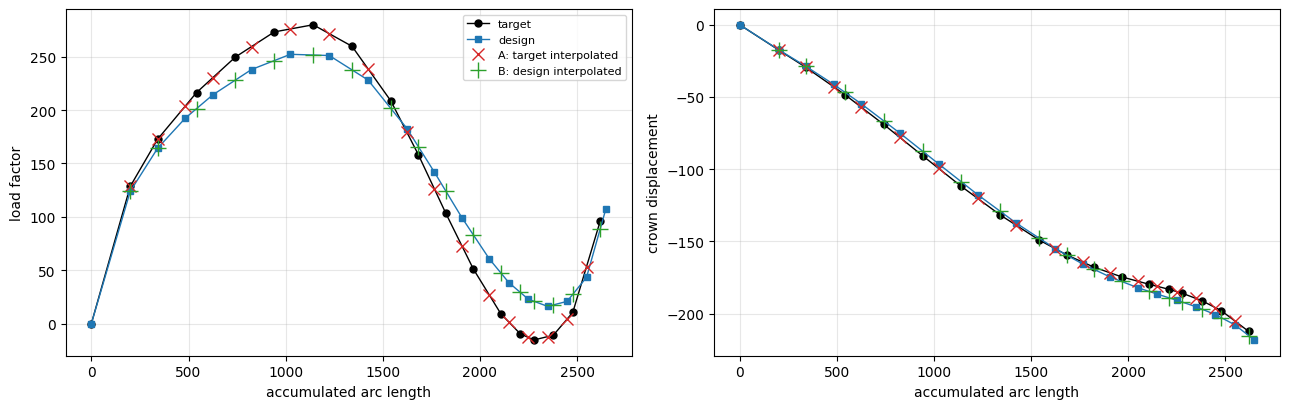

In [14]:
# The two schemes drawn out, in the arc-length space the objective works in.
s, u, lam, _, _ = Curve(x0, Sensitivity=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (yT, yD, Name) in zip(axes,
                              ((MSE.lamT, lam, 'load factor'),
                               (MSE.uT, u, 'crown displacement')), strict=True):
    ax.plot(MSE.sT, yT, 'o-', color='k', ms=5, lw=1, label='target')
    ax.plot(s, yD, 's-', color='tab:blue', ms=5, lw=1, label='design')

    # A samples at the design's arc lengths, interpolating the target onto them.
    At = s[1:][s[1:] <= MSE.sT[-1]]
    ax.plot(At, Interp(MSE.sT, yT, None, At)[0], 'x', color='tab:red', ms=9,
            label='A: target interpolated')

    # B samples at the target's, interpolating the design onto them.
    AtB = MSE.sT[1:][MSE.sT[1:] <= s[-1]]
    ax.plot(AtB, Interp(s, yD, None, AtB)[0], '+', color='tab:green', ms=11,
            label='B: design interpolated')

    ax.set(xlabel='accumulated arc length', ylabel=Name)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()

print(f'target has {len(MSE.sT)-1} steps, this design has {len(s)-1}')
print('The error is summed at the crosses for A and at the plusses for B.')

## 5. Solving the inverse problem with SLSQP

Start from a random arch and recover the target radii, using objective B and the analytical
gradient. The optimum is known — `[100, 100, 100, 100]` at $f = 0$ — so the answer is
checkable rather than merely plausible, and it is worth watching the exit message as much
as the radii.

Two things the driver has to handle: one arc-length solve yields both the value and the
gradient, so it caches on the design vector rather than solving twice; and some designs in
this box cannot be traced at all, so a failed solve returns a large value instead of
propagating the exception.

> Note: A proper FEM-in-the-Loop" run would require multiple random restarts to ensure a local minima isn't found. 
> This is omitted here for the sake of speed

In [15]:
from scipy.optimize import minimize


class Driver:
    """Objective B for SLSQP. One arc-length solve serves both value and gradient."""

    Untraceable = 1e3   # returned for a design the arc-length solver cannot follow

    def __init__(self, Objective):
        self.Objective = Objective
        self.x = None
        self.History = []          # (radii, f, arc steps) per distinct design solved

    def _At(self, x):
        if self.x is not None and np.array_equal(x, self.x):
            return

        self.x = np.copy(x)
        try:
            _, (self.f, self.g) = self.Objective(x)      # [1] is objective B
            Steps = self.Objective.Steps
        except RuntimeError:
            # Hand back a large value and no gradient so the line search backs
            # out of the region rather than the whole run dying.
            self.f, self.g, Steps = self.Untraceable, np.zeros_like(x), None
        self.History.append((np.copy(x), self.f, Steps))

    def Value(self, x):
        self._At(x)
        return self.f

    def Grad(self, x):
        self._At(x)
        return self.g


Seed = 0
Start = np.random.default_rng(Seed).uniform(80.0, 120.0, 4)

Drive = Driver(MSE)
Clock = time.perf_counter()
Result = minimize(Drive.Value, Start, jac=Drive.Grad, method='SLSQP',
                  bounds=[(80.0, 120.0)]*4,          # the paper's design box
                  options=dict(ftol=1e-12, maxiter=50))
Elapsed = time.perf_counter() - Clock

Steps = sorted({s for _, _, s in Drive.History if s is not None})
print(f'start   {np.array2string(Start, precision=3, floatmode="fixed")}')
print(f'found   {np.array2string(Result.x, precision=3, floatmode="fixed")}')
print(f'target  {np.array2string(np.full(4, R), precision=3, floatmode="fixed")}')
print(f'\nlargest radius error {np.max(np.abs(Result.x - R)):.4f} mm')
print(f'objective {Result.fun:.3e}, started at {Drive.History[0][1]:.3e}')
print(f'{Result.nit} iterations, {len(Drive.History)} solves, {Elapsed/60:.1f} min')
print(f'{Result.message}')
print(f'\narc step counts seen along the way: {Steps}')
print('More than one means the run crossed a discontinuity in the objective.'
      if len(Steps) > 1 else 'Only one, so the run never crossed a discontinuity.')

start   [105.478  90.791  81.639  80.661]
found   [102.295 106.621  89.306  89.519]
target  [100.000 100.000 100.000 100.000]

largest radius error 10.6936 mm
objective 3.334e-03, started at 1.431e-01
47 iterations, 118 solves, 85.7 min
Optimization terminated successfully

arc step counts seen along the way: [16, 17, 20, 21, 22, 23, 24, 25, 26, 30]
More than one means the run crossed a discontinuity in the objective.


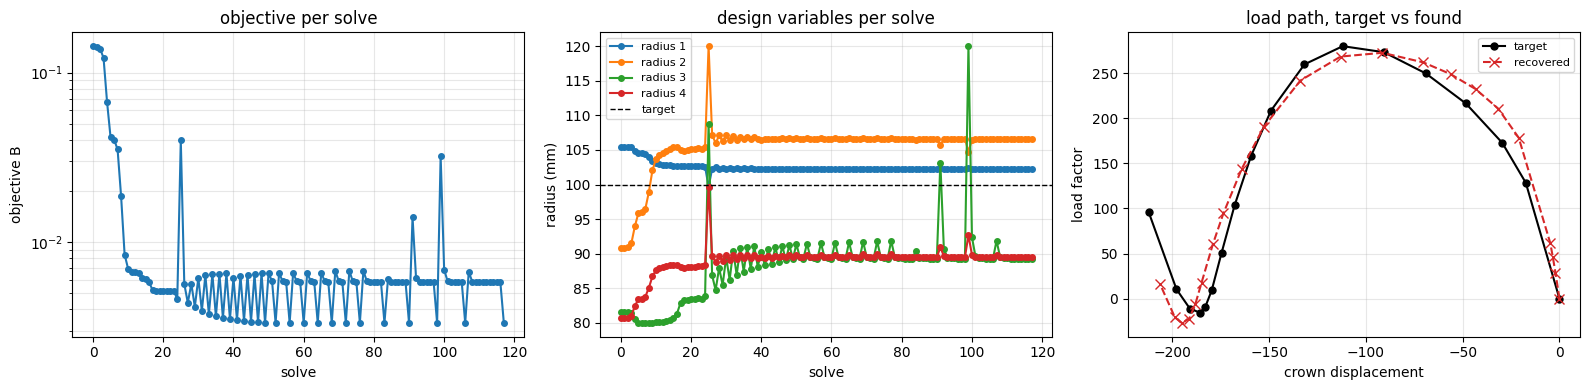

In [16]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.0))

Fs = [f for _, f, _ in Drive.History]
Xs = np.array([x for x, _, _ in Drive.History])

a1.semilogy(Fs, 'o-', ms=4)
a1.set(xlabel='solve', ylabel='objective B', title='objective per solve')
a1.grid(alpha=0.3, which='both')

for i in range(4):
    a2.plot(Xs[:, i], 'o-', ms=4, label=f'radius {i+1}')
a2.axhline(R, color='k', ls='--', lw=1, label='target')
a2.set(xlabel='solve', ylabel='radius (mm)', title='design variables per solve')
a2.legend(fontsize=8)
a2.grid(alpha=0.3)

sF, uF, lamF, _, _ = Curve(Result.x, Sensitivity=False)
a3.plot(MSE.uT, MSE.lamT, 'o-', color='k', ms=5, lw=1.5, label='target')
a3.plot(uF, lamF, 'x--', color='tab:red', ms=7, label='recovered')
a3.set(xlabel='crown displacement', ylabel='load factor', title='load path, target vs found')
a3.legend(fontsize=8)
a3.grid(alpha=0.3)
plt.tight_layout()

### What the analytical gradient is worth here

Timed against what SLSQP would otherwise do: one forward difference per variable, so
`1 + n` plain solves for `n` design variables. At this arc length a plain solve is
expensive — most steps retry — so the analytical gradient wins on time as well as on
accuracy, which it did not at the finer setting where the ratio was 0.91.

In [17]:
Probe = np.array([100.0, 105.0, 98.0, 102.0])
n = len(Probe)

Clock = time.perf_counter()
MSE(Probe, Sensitivity=True)
Analytic = time.perf_counter() - Clock

Clock = time.perf_counter()
for _ in range(1 + n):                      # the value, then one step per variable
    MSE(Probe, Sensitivity=False)
Difference = time.perf_counter() - Clock

print(f'one gradient at {n} design variables')
print(f'  analytical                        {Analytic:6.1f} s')
print(f'  {1+n} plain solves, {n} forward differences  {Difference:6.1f} s')
print(f'\nRatio {Analytic/Difference:.2f}. The analytical gradient also stays correct across a')
print('discontinuity, where a finite difference does not. Its cost is flat in the number of')
print('design variables while the difference grows linearly, so the gap widens as variables')
print(f'are added: at 16 the difference would need {(1 + 16)/(1 + n):.1f}x as many solves as it does here.')

one gradient at 4 design variables
  analytical                          33.0 s
  5 plain solves, 4 forward differences    65.3 s

Ratio 0.51. The analytical gradient also stays correct across a
discontinuity, where a finite difference does not. Its cost is flat in the number of
design variables while the difference grows linearly, so the gap widens as variables
are added: at 16 the difference would need 3.4x as many solves as it does here.


## 6. A gradient-only optimiser walks through it

SLSQP stopped because it decides termination from *function values*, and the adaptive arc
stepping makes those jump. The paper's answer is to define the optimum by gradient alone —
a **non-negative gradient projection point**, where the projected gradient changes sign
from negative to positive. Its own words: *"this definition of the optimal solution requires
only the gradient information of the objective function, since the objective function values
themselves are never used."*

**ADAM meets that criterion.** It builds its moments from the gradient, its update
$\text{lr}\cdot\hat m/(\sqrt{\hat v}+\epsilon)$ contains no function value, and it has no
line search to be fooled by a jump. Nothing in the loop below reads `f` — it is recorded for
the figure only.

**On step size.** ADAM's per-coordinate normalisation makes $|\hat m/\sqrt{\hat v}|\approx1$
while the gradient sign holds, so each radius moves about `Rate` per iteration and **`Rate`
is in millimetres**. That is the convenience: a raw subgradient step $x - \alpha\nabla f$
would need $\alpha\approx10^3$ to move a millimetre, since $\|\nabla f\|\approx3\times10^{-2}$
at the start and $2\times10^{-4}$ near the end — two orders of magnitude of drift that a
fixed $\alpha$ cannot absorb. The schedule is sized by travel budget: the furthest radius
starts 19.3 mm out, and `Rate/(1 − Decay)` = 50 mm is available.

Two things this section does *not* claim. The decaying step sets a floor on how finely the
search can resolve, but it is not what limits the answer below — the run plateaus well
before the step gets that small. And some designs in this box cannot be traced at all, so
the loop retries towards the last one that could; if it runs out of retries it stops early,
which is reported rather than hidden.

Everything else is held to section 5 — same objective B, same starting design, same mesh
and arc settings — so the optimiser is the only difference.

In [68]:
Rate, Decay, MaxIter = 3.0, 0.94, 40      # mm per step, geometric decay
Beta1, Beta2, Eps = 0.9, 0.999, 1e-8      # the usual ADAM constants
MaxBackOff = 5                            # feasibility retries within one iteration

# Names are deliberately not the textbook m and v: v is Poisson's ratio in the
# setup cell and Arch() reads it as a global, so shadowing it here would corrupt
# every solve from this point on.
Design = np.copy(Start)                   # the design SLSQP began from, unchanged
Mom1 = np.zeros_like(Design)
Mom2 = np.zeros_like(Design)
Good = np.copy(Design)                    # last design the arc-length solver could trace
AdamHistory = []                          # (radii, f, arc steps, |g|) per solve
BackOffs = 0

Clock = time.perf_counter()
for k in range(MaxIter):

    # Some designs in this box cannot be traced at all. Retry towards the last one
    # that could until the solver returns a path, so every iteration yields a
    # gradient. Only feasibility is consulted here, never a function value.
    for _ in range(MaxBackOff):
        try:
            # Objective B, same as SLSQP used. f is recorded for the figure below
            # and is never read by the algorithm -- that is the whole point.
            _, (f, g) = MSE(Design)
            break
        except RuntimeError:
            BackOffs += 1
            if not AdamHistory:
                raise RuntimeError(
                    'the starting design itself cannot be traced, so there is no '
                    'gradient to start from -- choose another Seed') from None
            Design = 0.5*(Design + Good)
            # The momentum is what carried it in here, so drop it rather than let
            # the next step charge straight back into the same region.
            Mom1 = np.zeros_like(Mom1)
            Mom2 = np.zeros_like(Mom2)
    else:
        print(f'stopped at iteration {k}: no traceable design within {MaxBackOff} back offs')
        break

    Good = np.copy(Design)
    AdamHistory.append((np.copy(Design), f, MSE.Steps, float(np.linalg.norm(g))))

    Mom1 = Beta1*Mom1 + (1 - Beta1)*g
    Mom2 = Beta2*Mom2 + (1 - Beta2)*g**2
    Mom1Hat = Mom1/(1 - Beta1**(k + 1))
    Mom2Hat = Mom2/(1 - Beta2**(k + 1))

    Design = np.clip(Design - Rate*Decay**k * Mom1Hat/(np.sqrt(Mom2Hat) + Eps),
                     80.0, 120.0)

AdamElapsed = time.perf_counter() - Clock
AdamX, AdamF, AdamStepCount, AdamGrad = AdamHistory[-1]
AdamSeen = sorted({s for _, _, s, _ in AdamHistory})

Summary = [('start', Start), ('SLSQP', Result.x), ('ADAM', AdamX), ('target', np.full(4, R))]
print(f"{'':<8}{'radii':^36}{'largest error':>16}")
for Name, Radii in Summary:
    Error = '' if Name == 'target' else f'{np.max(np.abs(Radii - R)):>13.4f} mm'
    print(f'{Name:<8}{np.array2string(Radii, precision=3, floatmode="fixed"):^36}{Error}')

print(f'\nADAM  objective {AdamF:.3e}, |g| {AdamGrad:.2e}')
print(f'      {len(AdamHistory)} solves, {BackOffs} back offs, {AdamElapsed/60:.1f} min')
# The scheduled final step only applies if the run used its whole budget, so report
# the step actually taken at the last iteration alongside it.
print(f'      last step taken {Rate*Decay**(len(AdamHistory) - 1):.2f} mm, '
      f'schedule would reach {Rate*Decay**(MaxIter - 1):.2f} mm at iteration {MaxIter}')
print(f'SLSQP objective {Result.fun:.3e}, {len(Drive.History)} solves, "{Result.message}"')
print(f'\narc step counts seen: ADAM  {AdamSeen}')
print(f'                      SLSQP {sorted({s for _, _, s in Drive.History if s is not None})}')

stopped at iteration 27: no traceable design within 5 back offs
                       radii                   largest error
start    [105.478  90.791  81.639  80.661]        19.3389 mm
SLSQP    [102.295 106.621  89.306  89.519]        10.6936 mm
ADAM       [95.033 99.359 94.361 97.712]           5.6394 mm
target   [100.000 100.000 100.000 100.000]  

ADAM  objective 4.097e-04, |g| 2.25e-04
      27 solves, 16 back offs, 22.2 min
      last step taken 0.60 mm, schedule would reach 0.27 mm at iteration 40
SLSQP objective 3.334e-03, 118 solves, "Optimization terminated successfully"

arc step counts seen: ADAM  [18, 19, 20, 21, 23, 24, 25, 26]
                      SLSQP [16, 17, 20, 21, 22, 23, 24, 25, 26, 30]


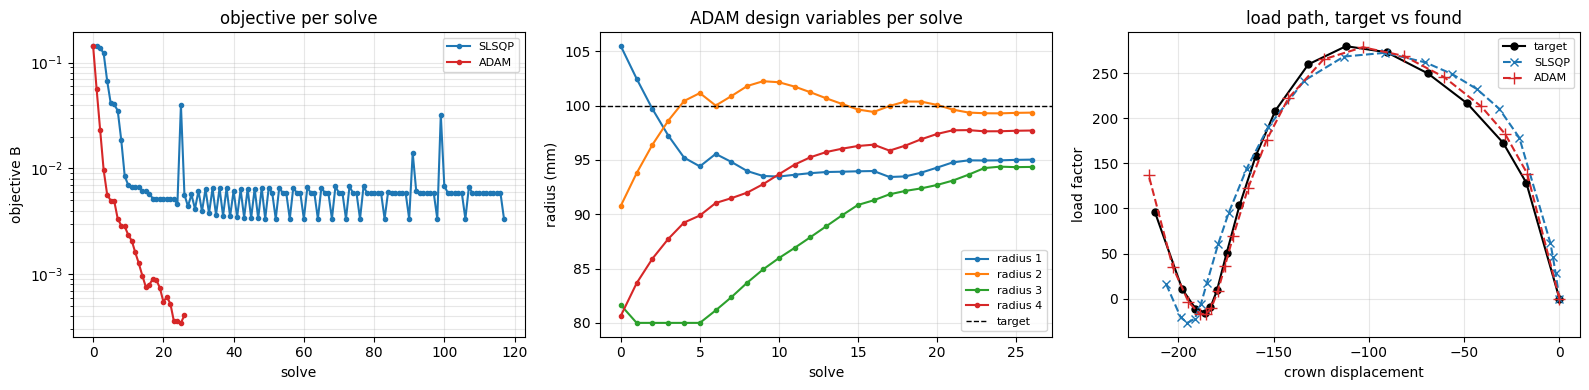

In [19]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.0))

AdamValues = [Value for _, Value, _, _ in AdamHistory]
AdamRadii = np.array([Radii for Radii, _, _, _ in AdamHistory])
SlsqpValues = [Value for _, Value, _ in Drive.History]

a1.semilogy(SlsqpValues, 'o-', ms=3, color='tab:blue', label='SLSQP')
a1.semilogy(AdamValues, 'o-', ms=3, color='tab:red', label='ADAM')
a1.set(xlabel='solve', ylabel='objective B', title='objective per solve')
a1.legend(fontsize=8)
a1.grid(alpha=0.3, which='both')

for i in range(4):
    a2.plot(AdamRadii[:, i], 'o-', ms=3, label=f'radius {i+1}')
a2.axhline(R, color='k', ls='--', lw=1, label='target')
a2.set(xlabel='solve', ylabel='radius (mm)', title='ADAM design variables per solve')
a2.legend(fontsize=8)
a2.grid(alpha=0.3)

# uF, lamF are SLSQP's recovered path, computed in the section 5 figure above.
_, uA, lamA, _, _ = Curve(AdamX, Sensitivity=False)
a3.plot(MSE.uT, MSE.lamT, 'o-', color='k', ms=5, lw=1.5, label='target')
a3.plot(uF, lamF, 'x--', color='tab:blue', ms=6, label='SLSQP')
a3.plot(uA, lamA, '+--', color='tab:red', ms=8, label='ADAM')
a3.set(xlabel='crown displacement', ylabel='load factor', title='load path, target vs found')
a3.legend(fontsize=8)
a3.grid(alpha=0.3)
plt.tight_layout()